In [13]:
import re
from pathlib import Path

import fire
import jsonlines
import numpy as np
from loguru import logger

from fourier_supervised_cleanroom import (
    fit_fourier_series,
    hadamard_transform,
    keep_largest_n,
    mk_train_test,
    sign_signal,
)
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from misc_utils import keep_serializable
from spin_lattices import KagomeLattice, SquareLattice, TriangularLattice

from fourier_supervised_truncation import output_dir
from misc_utils import read_jsonl_to_df
import seaborn as sns

In [7]:
list(output_dir.glob("*"))

[PosixPath('experiments/fourier_supervised_truncation/0')]

In [16]:
df = read_jsonl_to_df(output_dir.glob("**/results.jsonl"))

In [18]:
df.groupby(["lattice", "J2", "initial_keep_terms"])['accuracy'].max()

lattice        J2   initial_keep_terms
triangular6x4  1.3  11                    1.00000
                    121                   0.96616
                    1339                  0.90942
                    14764                 0.88058
                    162754                0.82152
                    1794074               0.80702
                    19776402              0.80468
                    217998774             0.80874
                    2403038944            0.80704
                    26489122129           0.80880
Name: accuracy, dtype: float64

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


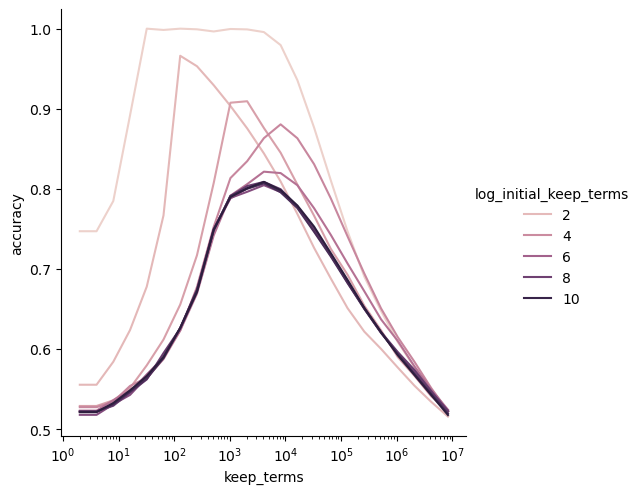

In [22]:
sns.relplot(
    df.assign(log_initial_keep_terms=lambda df: np.log(df["initial_keep_terms"]) / np.log(10)),
    x="keep_terms",
    y="accuracy",
    hue="log_initial_keep_terms",
    kind="line",
).set(xscale="log")